In [ ]:
# !pip install langchain
# !pip install pypdf
# !pip install chromadb
# !pip install -U langsmith
# !pip install langchain_community
# ! pip install openai langchain_openai langchain_chroma langchain-classic

#  CHAT WITH YOUR DATA 


-- ABHISHEK CHORARIA

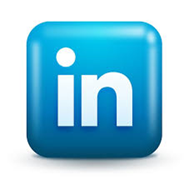
[here](https://www.linkedin.com/in/abhishek-choraria-b0966a67?utm_source=share&utm_campaign=share_via&utm_content=profile&utm_medium=android_app ).

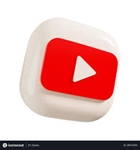
[here](https://www.youtube.com/@Aiburner_official)

In [ ]:
import os
import openai

from dotenv import load_dotenv, find_dotenv
load_dotenv()

openai.api_key  = os.getenv('OPENAI_API_KEY')

os.environ["LANGCHAIN_TRACING_V2"]="true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"]= os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = "CHAT WITH YOUR DATA"

In [1]:
# print(os.getenv("Langchain_api"))

In [2]:
# print(os.getenv('OPENAI_API_KEY'))

# [1] Load aczel

In [36]:
from langchain_community.document_loaders import PyPDFLoader

In [37]:
file_path = r"C:\Users\abhim\OneDrive\Documents\Projects\RAG evaluation with RAGAS\Business Statistics - A. Aczel, J. Sounderpandian.pdf"
loader = PyPDFLoader(file_path)
pages = loader.load()

In [5]:
print(f"Total number of pages : {len(pages)}")

Total number of pages : 888


### Select Chapter 1 

In [ ]:
print(f"Chapter 1 : {pages[7:47]}")

In [39]:
page = pages[7:48]
# for i in page:
#     print(i.page_content)

In [8]:
print(f"Length of pages {len(page)}")

Length of pages 41


In [ ]:
for i in page:
    print(i.metadata)
# print(f"Metadata of page 10 is {page.metadata}")

# [2] Splitting Documnets

In [40]:
# Split
from langchain_text_splitters import RecursiveCharacterTextSplitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1500,
    chunk_overlap = 150
)

In [41]:
docs = text_splitter.split_documents(page)

In [12]:
# print(docs)

In [42]:
print(f"Length of document before splitting {len(page)}")
print(f"Length of document after splitting {len(docs)}")

Length of document before splitting 41
Length of document after splitting 92


In [14]:
# new_doc =docs[8:19]

In [15]:
# docs[0].page_content

In [43]:
for i in range(2):
    print(f"Documnet {i} is \n\n-----\n\n {docs[i]} \n -------- \n")

Documnet 0 is 

-----

 page_content='Aczel−Sounderpandian: 
Complete Business 
Statistics, Seventh Edition
1. Introduction and 
Descriptive Statistics
Text
4 © The McGraw−Hill 
Companies, 2009
1
1
1
1
1
1
1
1
1
1
1
1
2
1–1 Using Statistics 3
1–2 Percentiles and Quartiles 8
1–3 Measures of Central Tendency 10
1–4 Measures of Variability 14
1–5 Grouped Data and the Histogram 20
1–6 Skewness and Kurtosis 22
1–7 Relations between the Mean and the Standard 
Deviation 24
1–8 Methods of Displaying Data 25
1–9 Exploratory Data Analysis 29
1–10 Using the Computer 35
1–11 Summary and Review of Terms 41
Case 1 NASDAQ Volatility 48
1
After studying this chapter, you should be able to:
• Distinguish between qualitative and quantitative data.
• Describe nominal, ordinal, interval, and ratio scales of
measurement.
• Describe the difference between a population and a sample.
• Calculate and interpret percentiles and quartiles.
• Explain measures of central tendency and how to compute
them.
• Create d

# [3] Embeddings

- Use openAi emeddings

In [17]:
# print(os.getenv('OPENAI_API_KEY'))

In [44]:
import os 
os.environ["OPENAI_API_KEY"] = os.getenv('OPENAI_API_KEY')

In [45]:
from langchain_openai import OpenAIEmbeddings
embedding = OpenAIEmbeddings()

In [20]:
# from langchain_community.embeddings import HuggingFaceEmbeddings

# model_name = "sentence-transformers/all-mpnet-base-v2"
# model_kwargs = {'device': 'cpu'}
# encode_kwargs = {'normalize_embeddings': False}
# hf = HuggingFaceEmbeddings(
#     model_name=model_name,
#     model_kwargs=model_kwargs,
#     encode_kwargs=encode_kwargs
# )

# [4] Vectorstores

In [21]:
# !pip install langchain_pinecone

In [46]:
from langchain_chroma import Chroma
# from langchain_community.vectorstores import FAISS
# from langchain_pinecone import PineconeVectorStore

In [23]:
# index_name = "langchain-aczel-index"

# vectordb = PineconeVectorStore.from_documents(docs, embedding, index_name=index_name)

In [24]:
os.getcwd()

'd:\\Data Science\\Playfully serious'

In [25]:
# !rd -rf ./docs/chroma  # remove old database files if any

In [26]:
# !rmdir /q ./docs/chroma
# !rmdir /s /q ".\docs\chroma"


### Making a vector store for chapter 1

In [27]:
# !pip install chromadb

In [28]:
# 
# !pip install pinecone

In [47]:
persist_directory = 'docs/chroma/'
vectordb =Chroma.from_documents(
    documents=docs,
    embedding=embedding,
    persist_directory = persist_directory
)

In [48]:
print(vectordb._collection.count())

92


#### [a] Similarity search

In [49]:
question = "what is measure of central tendency ?"

In [50]:
answer = vectordb.similarity_search(question,k=3)

In [51]:
len(answer)

3

In [52]:
answer[0]

Document(id='f246348d-b476-4bad-8f11-44fa889dd106', metadata={'creator': 'PyPDF', 'producer': 'iTextSharp 5.1.0 (c) 1T3XT BVBA', 'page_label': '43', 'total_pages': 888, 'creationdate': '', 'page': 46, 'moddate': '2011-06-05T15:38:24+02:00', 'source': 'C:\\Users\\abhim\\OneDrive\\Documents\\Projects\\RAG evaluation with RAGAS\\Business Statistics - A. Aczel, J. Sounderpandian.pdf'}, page_content='mean. We called the mean the most important measure of central tendency, or loca-\ntion, of the data set. We said that the mean is the average of all the data points and is\nthe point where the entire distribution of data points balances.\nWe deﬁned measures of variability: the range, the variance, and the standard\ndeviation. We deﬁned the range as the difference between the largest and smallest\ndata points. The variance was deﬁned as the average squared deviation of the data\npoints from their mean. For a sample (rather than a population), we saw that this aver-\naging is done by dividing th

In [54]:
answer[1]

Document(id='0f99d5ff-0fdc-4e68-a08c-8ce14c830e53', metadata={'total_pages': 888, 'creationdate': '', 'page': 18, 'source': 'C:\\Users\\abhim\\OneDrive\\Documents\\Projects\\RAG evaluation with RAGAS\\Business Statistics - A. Aczel, J. Sounderpandian.pdf', 'moddate': '2011-06-05T15:38:24+02:00', 'page_label': '15', 'creator': 'PyPDF', 'producer': 'iTextSharp 5.1.0 (c) 1T3XT BVBA'}, page_content='Aczel−Sounderpandian: \nComplete Business \nStatistics, Seventh Edition\n1. Introduction and \nDescriptive Statistics\nText\n15© The McGraw−Hill \nCompanies, 2009\nFIGURE 1–2 A Symmetrically Distributed Data Set\nMean = Median = Mode\nx\n1–18. Discuss the differences among the three measures of centrality.\n1–19. Find the mean, median, and mode(s) of the observations in problem 1–13.\n1–20. Do the same as problem 1–19, using the data of problem 1–14.\n1–21. Do the same as problem 1–19, using the data of problem 1–15.\n1–22. Do the same as problem 1–19, using the data of problem 1–16.\n1–23. Do 

In [55]:
answer[2]

Document(id='118da513-c280-4e37-83ec-59fcd6e0a20b', metadata={'page_label': '13', 'producer': 'iTextSharp 5.1.0 (c) 1T3XT BVBA', 'total_pages': 888, 'creationdate': '', 'moddate': '2011-06-05T15:38:24+02:00', 'page': 16, 'creator': 'PyPDF', 'source': 'C:\\Users\\abhim\\OneDrive\\Documents\\Projects\\RAG evaluation with RAGAS\\Business Statistics - A. Aczel, J. Sounderpandian.pdf'}, page_content='Aczel−Sounderpandian: \nComplete Business \nStatistics, Seventh Edition\n1. Introduction and \nDescriptive Statistics\nText\n13© The McGraw−Hill \nCompanies, 2009\nFIGURE 1–1 Mean, Median, and Mode for Example 1–2\nMode Median (26.9)\nMean\n18 20 22 24 26 28 30 32 34 36 38 40 42 44 46 48 50 52 54 56\nx\nWhen our observation set constitutes an entire population, instead of denoting the\nmean by we use the symbol /H9262(the Greek letter mu). For a population, we use N as\nthe number of elements instead of n. The population mean is deﬁned as follows.\nx\nIntroduction and Descriptive Statistics 11\

### [b] using Maximum marginality relevance

In [56]:
answer_MMR = vectordb.max_marginal_relevance_search(question,k=3)

In [59]:
answer_MMR[0].page_content[200:500]

'istribution of data points balances.\nWe deﬁned measures of variability: the range, the variance, and the standard\ndeviation. We deﬁned the range as the difference between the largest and smallest\ndata points. The variance was deﬁned as the average squared deviation of the data\npoints from their mean'

## [d]  compression

Another approach for improving the quality of retrieved docs is compression.

Information most relevant to a query may be buried in a document with a lot of irrelevant text. 

Passing that full document through your application can lead to more expensive LLM calls and poorer responses.

Contextual compression is meant to fix this. 

In [60]:
import warnings
warnings.filterwarnings('ignore')

In [26]:
# from langchain.retrievers import ContextualCompressionRetriever
# from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain_classic.retrievers import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import LLMChainExtractor


In [61]:
def pretty_print_docs(docs):
    print(f"\n{'-' * 100}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(docs)]))


In [62]:
# Wrap our vectorstore
# from langchain.llms import OpenAI
from langchain.chat_models import init_chat_model
llm = init_chat_model("gpt-4.1")
# llm = OpenAI(temperature=0)
compressor = LLMChainExtractor.from_llm(llm)

In [63]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=vectordb.as_retriever(search_type='mmr')
)

In [71]:
question = "what is boxplot ?"
compressed_docs = compression_retriever.invoke(question)
pretty_print_docs(compressed_docs)

Document 1:

box plot are essentially the quartiles of the data set. (We will deﬁne hinges shortly.) The
median is a line inside the box.
----------------------------------------------------------------------------------------------------
Document 2:

Box plots are very useful for the following purposes.
1. T o identify the location of a data set based on the median.
2. T o identify the spread of the data based on the length of the box, hinge to
hinge (the interquartile range), and the length of the whiskers (the range of the
data without extreme observations: outliers or suspected outliers).
3. T o identify possible skewness of the distribution of the data set. If the portion
of the box to the right of the median is longer than the portion to the left of the
median, and/or the right whisker is longer than the left whisker, the data are
right-skewed. Similarly, a longer left side of the box and/or left whisker implies
a left-skewed data set. If the box and whiskers are symmetric, the d

In [3]:
# import datetime
# current_date = datetime.datetime.now().date()
# if current_date < datetime.date(2023, 9, 2):
#     llm_name = "gpt-3.5-turbo-0301"
# else:
#     llm_name = "gpt-3.5-turbo"
# print(llm_name)

gpt-3.5-turbo-0301


In [6]:
# from langchain.chat_models import ChatOpenAI
# llm = ChatOpenAI(model_name=llm_name, temperature=0)

### RetrievalQA chain

In [25]:
# from langchain.chains import RetrievalQA
from langchain_classic.chains.retrieval_qa.base import RetrievalQA


- Using retriever as **Compression retriever**

In [72]:
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=compression_retriever
)

In [81]:
question = "hey what is my name"

In [82]:

result = qa_chain({"query": question})

In [83]:
print(result["result"])

I don't know your name, as you haven't provided it. If you'd like to share your name, feel free to let me know!


- Using retriever as **vectordb retriever**

In [56]:
qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=vectordb.as_retriever()
)

result = qa_chain({"query": question})

result["result"]

' A box plot is a graphical representation of a data set that shows the median, lower and upper quartiles, and the range of the data. It is used to identify the central tendency, spread, skewness, and outliers in a data set.'

In [ ]:
print(qa_chain)

### Prompt

In [30]:
from langchain_core.prompts import PromptTemplate

# Build prompt
template = """Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer. Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer. 
{context}
Question: {question}
Helpful Answer:"""
QA_CHAIN_PROMPT = PromptTemplate.from_template(template)


In [61]:
print(QA_CHAIN_PROMPT)

input_variables=['context', 'question'] template='Use the following pieces of context to answer the question at the end. If you don\'t know the answer, just say that you don\'t know, don\'t try to make up an answer. Use three sentences maximum. Keep the answer as concise as possible. Always say "thanks for asking!" at the end of the answer. \n{context}\nQuestion: {question}\nHelpful Answer:'


In [62]:
# Run chain

qa_chain = RetrievalQA.from_chain_type(
    llm,
    retriever=compression_retriever,
    return_source_documents=True,
    chain_type_kwargs={"prompt": QA_CHAIN_PROMPT}
)


In [63]:
question = "Can i learn about box plot after reading this chapter?"

In [64]:
result = qa_chain({"query": question})

In [65]:
result["result"]

' Yes, you can learn about box plots after reading this chapter. The chapter discusses how box plots can be used to identify the location, spread, and skewness of a data set. It also explains how to interpret box plots and how they can be used to compare two populations. Thanks for asking!'

- **Question[2]**

In [49]:
question = "What topics are covered in this chapter ?"

In [50]:
result = qa_chain({"query": question})

In [51]:
result["result"]

' This chapter covers the use of MINITAB for producing descriptive statistics and corresponding plots, including percentiles and quartiles, measures of central tendency and variability, grouped data and histograms, skewness and kurtosis, and methods of displaying data. It also discusses exploratory data analysis and the use of computers for obtaining descriptive statistics. Thanks for asking!'

# [5] Create Memory to have the functionality of chatbot

- Above questions doesnt take in the conversation into account. To keep the previous converation into account we need to **assign memory.**

### [a] Memory

In [90]:
from langchain_classic.memory import ConversationBufferMemory
memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True
)

### [b] ConversationalRetrievalChain

In [91]:
from langchain_classic.chains import ConversationalRetrievalChain
retriever=compression_retriever
qa = ConversationalRetrievalChain.from_llm(
    llm,
    retriever=retriever,
    memory=memory
)

In [68]:
import logging

# Suppress warnings from langchain.llms module
logger = logging.getLogger("langchain.llms")
logger.setLevel(logging.ERROR)

- **Question 1**

In [94]:
question = "what is my name"
result = qa({"question": question})
result

{'question': 'what is my name',
 'chat_history': [HumanMessage(content='what did i say in my first message ?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='You asked: "what did i say in my first message ?"', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='hey am abhishek', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Hello Abhishek! How can I help you today?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  HumanMessage(content='what is my name', additional_kwargs={}, response_metadata={}),
  AIMessage(content="I'm sorry, but I don't know your name.", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])],
 'answer': "I'm sorry, but I don't know your name."}

' This chapter is about using statistics, including measures of central tendency and variability, to analyze and display data.'

- **Question 2**

In [57]:
question = "With respect to above topics, what kind of knowledge should i have before reading this chapter?"
result = qa({"question": question})
result['answer']

' Before reading this chapter, it would be helpful to have a basic understanding of statistics and its purpose in making better decisions in various fields. It would also be beneficial to have knowledge of the different scales of measurement for data and various graphical techniques used in exploratory data analysis. Additionally, understanding the importance of randomization in experiments and data collection would be useful.'

- **question 3**

In [58]:
question = "What is shape of distribution ?"
result = qa({"question": question})
result['answer']

' The shape of the distribution can be described by its kurtosis, which is a measure of the peakedness or flatness of the distribution. In this context, kurtosis refers to the relative kurtosis, which can be negative or positive. A negative kurtosis indicates a flatter distribution than the normal distribution, while a positive kurtosis indicates a more peaked distribution. The empirical rule, which states that approximately 68% of the data falls within one standard deviation of the mean, may not hold for distributions with high kurtosis. This means that the data may not be symmetric and may have more extreme values than a normal distribution. '

- **Question 4**

In [59]:
question = "what is boxplot ?"
result = qa({"question": question})
result['answer']

' A boxplot is a graphical representation of a data set that shows the distribution of the data and identifies any outliers or extreme values. It consists of a box with a line in the middle (the median), and "whiskers" that extend from the box to show the range of the data. Boxplots are useful for identifying the location and spread of a data set, as well as any skewness in the data. They can also be used to compare two data sets and identify any differences or similarities.'

- **Question 5**

In [46]:
question = "What is measure of central tendency ?"
result = qa({"question": question})

In [47]:
result['answer']

' A measure of central tendency is a summary statistic that describes the center of a data set. Examples of measures of central tendency include the mean, median, and mode.'

# [6] Create a chatbot that works on your documents

In [ ]:
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain.vectorstores import DocArrayInMemorySearch
from langchain.document_loaders import TextLoader
from langchain.chains import RetrievalQA,  ConversationalRetrievalChain
from langchain.memory import ConversationBufferMemory
from langchain.chat_models import ChatOpenAI
from langchain.document_loaders import TextLoader
from langchain.document_loaders import PyPDFLoader
import panel as pn
import param

The chatbot code has been updated a bit since filming. The GUI appearance also varies depending on the platform it is running on.

In [2]:
def load_db(file, chain_type, k):
    # load documents
    loader = PyPDFLoader(file)
    documents = loader.load()
    page = documents[7:48]
    # split documents
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=150)
    docs = text_splitter.split_documents(page)
    # define embedding
    embeddings = OpenAIEmbeddings()
    # create vector database from data
    db = DocArrayInMemorySearch.from_documents(docs, embeddings)
    # define retriever
    retriever = db.as_retriever(search_type="mmr", search_kwargs={"k": k})
    # create a chatbot chain. Memory is managed externally.
    qa = ConversationalRetrievalChain.from_llm(
        llm=ChatOpenAI(model_name="gpt3.5", temperature=0), 
        chain_type=chain_type, 
        retriever=retriever, 
        return_source_documents=True,
        return_generated_question=True,
    )
    return qa 


In [3]:
import panel as pn
import param

class cbfs(param.Parameterized):
    chat_history = param.List([])
    answer = param.String("")
    db_query  = param.String("")
    db_response = param.List([])
    
    def __init__(self,  **params):
        super(cbfs, self).__init__( **params)
        self.panels = []
        self.loaded_file = "Business_Statistics_Complete_Business_St_aczel.pdf"
        self.qa = load_db(self.loaded_file,"stuff", 4)
    
    def call_load_db(self, count):
        if count == 0 or file_input.value is None:  # init or no file specified :
            return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")
        else:
            file_input.save("Business_Statistics_Complete_Business_St_aczel.pdf")  # local copy
            self.loaded_file = file_input.filename
            button_load.button_style="outline"
            self.qa = load_db("Business_Statistics_Complete_Business_St_aczel.pdf", "stuff", 4)
            button_load.button_style="solid"
        self.clr_history()
        return pn.pane.Markdown(f"Loaded File: {self.loaded_file}")

    def convchain(self, query):
        if not query:
            return pn.WidgetBox(pn.Row('User:', pn.pane.Markdown("", width=600)), scroll=True)
        result = self.qa({"question": query, "chat_history": self.chat_history})
        self.chat_history.extend([(query, result["answer"])])
        self.db_query = result["generated_question"]
        self.db_response = result["source_documents"]
        self.answer = result['answer'] 
        self.panels.extend([
            pn.Row('User:', pn.pane.Markdown(query, width=600)),
            pn.Row('ChatBot:', pn.pane.Markdown(self.answer, width=600, style={'background-color': '#F6F6F6'}))
        ])
        inp.value = ''  #clears loading indicator when cleared
        return pn.WidgetBox(*self.panels,scroll=True)

    @param.depends('db_query ', )
    def get_lquest(self):
        if not self.db_query :
            return pn.Column(
                pn.Row(pn.pane.Markdown(f"Last question to DB:", styles={'background-color': '#F6F6F6'})),
                pn.Row(pn.pane.Str("no DB accesses so far"))
            )
        return pn.Column(
            pn.Row(pn.pane.Markdown(f"DB query:", styles={'background-color': '#F6F6F6'})),
            pn.pane.Str(self.db_query )
        )

    @param.depends('db_response', )
    def get_sources(self):
        if not self.db_response:
            return 
        rlist=[pn.Row(pn.pane.Markdown(f"Result of DB lookup:", styles={'background-color': '#F6F6F6'}))]
        for doc in self.db_response:
            rlist.append(pn.Row(pn.pane.Str(doc)))
        return pn.WidgetBox(*rlist, width=600, scroll=True)

    @param.depends('convchain', 'clr_history') 
    def get_chats(self):
        if not self.chat_history:
            return pn.WidgetBox(pn.Row(pn.pane.Str("No History Yet")), width=600, scroll=True)
        rlist=[pn.Row(pn.pane.Markdown(f"Current Chat History variable", styles={'background-color': '#F6F6F6'}))]
        for exchange in self.chat_history:
            rlist.append(pn.Row(pn.pane.Str(exchange)))
        return pn.WidgetBox(*rlist, width=600, scroll=True)

    def clr_history(self,count=0):
        self.chat_history = []
        return 


### Create a chatbot

In [4]:
cb = cbfs()
# Load the Panel extension
pn.extension()
file_input = pn.widgets.FileInput(accept='.pdf')
button_load = pn.widgets.Button(name="Load DB", button_type='primary')
button_load.on_click(cb.call_load_db)
button_clearhistory = pn.widgets.Button(name="Clear History", button_type='warning')
button_clearhistory.on_click(cb.clr_history)
inp = pn.widgets.TextInput( placeholder='Enter text here…')


bound_button_load = pn.bind(cb.call_load_db, button_load.param.clicks)
conversation = pn.bind(cb.convchain, inp) 


jpg_pane = pn.pane.Image( './img/convchain.jpg')

send_question_button = pn.widgets.Button(name="Send Question", button_type='primary')
send_question_button.on_click(cb.convchain)

tab1 = pn.Column(
    pn.Row(inp),
    pn.layout.Divider(),
    pn.panel(conversation,  loading_indicator=True, height=300),
    pn.layout.Divider(),
)
tab2= pn.Column(
    pn.panel(cb.get_lquest),
    pn.layout.Divider(),
    pn.panel(cb.get_sources ),
)
tab3= pn.Column(
    pn.panel(cb.get_chats),
    pn.layout.Divider(),
)
tab4=pn.Column(
    pn.Row( file_input, button_load, bound_button_load),
    pn.Row( button_clearhistory, pn.pane.Markdown("Clears chat history. Can use to start a new topic" )),
    pn.layout.Divider(),
    pn.Row(jpg_pane.clone(width=400))
)
dashboard = pn.Column(
    pn.Row(pn.pane.Markdown('# ChatWithYourData_Bot')),
    pn.Tabs(('Conversation', tab1), ('Database', tab2), ('Chat History', tab3),('Configure', tab4))
)


dashboard

Column
    [0] Row
        [0] Markdown(str)
    [1] Tabs
        [0] Column
            [0] Row
                [0] TextInput(placeholder='Enter text here…')
            [1] Divider()
            [2] ParamFunction(function, _pane=WidgetBox, defer_load=False, height=300, loading_indicator=True)
            [3] Divider()
        [1] Column
            [0] ParamMethod(method, _pane=Column, defer_load=False)
            [1] Divider()
            [2] ParamMethod(method, _pane=Str, defer_load=False)
        [2] Column
            [0] ParamMethod(method, _pane=WidgetBox, defer_load=False)
            [1] Divider()
        [3] Column
            [0] Row
                [0] FileInput(accept='.pdf')
                [1] Button(button_type='primary', name='Load DB')
                [2] ParamFunction(function, _pane=Markdown, defer_load=False)
            [1] Row
                [0] Button(button_type='warning', name='Clear History')
                [1] Markdown(str)
            [2] Divider()
            [3] Row
                [0] Image(str, width=400)

Feel free to copy this code and modify it to add your own features. You can try alternate memory and retriever models by changing the configuration in `load_db` function and the `convchain` method. [Panel](https://panel.holoviz.org/) and [Param](https://param.holoviz.org/) have many useful features and widgets you can use to extend the GUI.
